# Task 1 — Data Cleaning, Feature Engineering & Customer Segmentation

Complete assessment workflow: EDA, column-by-column cleaning, feature engineering, preprocessing, cluster selection, K-Means training, profiling, and model export.

In [1]:
from pathlib import Path
import re, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

DATA = Path("../data/task1_customer_segmentation_dataset.csv")
df = pd.read_csv(DATA)
print("Raw shape:", df.shape)
display(df.head())


mkdir -p failed for path C:\Users\pnred\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\pnred\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\pnred\AppData\Local\Temp\matplotlib-3l9w7uk3 because there was an issue with the default path (C:\Users\pnred\AppData\Local\matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Raw shape: (100200, 14)


,customer_id,age,gender,signup_date,last_login_date,contract_type,internet_service,payment_method,monthly_charges,total_charges,num_support_calls,credit_score,referral_code,plan_details
0,CUST167695,32,Female,2021-03-22,2026-05-30,Two year,No,Mailed check,95.09,5407.59,1,714.0,VWTEQKT8,Premium Plan - $95.09/mo - 100Mbps
1,CUST186221,60,Male,2025-08-24,2026-04-29,One year,Fiber optic,UPI,58.56,575.55,2,636.0,G6RAJJZP,Standard Plan - $58.56/mo - 25Mbps
2,CUST189615,33,Male,2025-12-30,2026-05-06,One year,Fiber optic,Credit card,42.88,219.83,1,674.0,BEZ0498P,Standard Plan - $42.88/mo - 50Mbps
3,CUST170559,65,Female,2023-11-06,2025-09-25,Month-to-month,Fiber optic,UPI,71.86,2343.82,2,NaN,1283Z6X4,Basic Plan - $71.86/mo - 100Mbps
4,CUST162052,60,Male,2025-10-03,2026-05-20,Two year,Fiber optic,UPI,64.15,519.22,3,NaN,NBEOT70S,Basic Plan - $64.15/mo - 500Mbps


## 1. Exploratory data analysis and data quality

In [2]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2),
    "unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)
display(quality)
print("Exact duplicate rows:", df.duplicated().sum())
print("Unique customer IDs:", df["customer_id"].nunique())
display(df.describe(include="all").T)


,dtype,missing,missing_pct,unique
credit_score,float64,60074,59.95,448
referral_code,str,20333,20.29,79701
total_charges,float64,2978,2.97,86208
gender,str,0,0.00,3
customer_id,str,0,0.00,100000
age,int64,0,0.00,57
contract_type,str,0,0.00,3
last_login_date,str,0,0.00,335
signup_date,str,0,0.00,2090
internet_service,str,0,0.00,3


Exact duplicate rows: 200
Unique customer IDs: 100000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,100200,100000,CUST187893,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100200.0,NaN,NaN,NaN,45.953543,16.436217,18.0,32.0,46.0,60.0,74.0
gender,100200,3,Female,48084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,100200,2090,2025-10-20,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_login_date,100200,335,2026-05-14,3006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,100200,3,Month-to-month,46907,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,100200,3,Fiber optic,45026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,100200,4,UPI,25160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_charges,100200.0,NaN,NaN,NaN,66.699514,24.172488,15.0,48.8175,64.26,84.0,150.0
total_charges,97222.0,NaN,NaN,NaN,2124.638681,1849.214951,4.53,456.88,1682.01,3290.8,9859.6


In [3]:
# Additional requested data-quality checks
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())
parsed_dates = {c: pd.to_datetime(df[c], errors="coerce") for c in ["signup_date", "last_login_date"]}
print("Invalid date counts:", {c: int(v.isna().sum()) for c,v in parsed_dates.items()})
print("Login before signup:", int((parsed_dates["last_login_date"] < parsed_dates["signup_date"]).sum()))
print("Login after fixed reference date 2026-06-01:", int((parsed_dates["last_login_date"] > pd.Timestamp("2026-06-01")).sum()))
print("Impossible-value checks:", {
    "age_outside_0_120": int((~df["age"].between(0,120)).sum()),
    "negative_monthly_charges": int((df["monthly_charges"] < 0).sum()),
    "negative_total_charges": int((df["total_charges"] < 0).sum()),
    "negative_support_calls": int((df["num_support_calls"] < 0).sum()),
    "credit_score_outside_300_900": int((~df["credit_score"].dropna().between(300,900)).sum()),
})
print("Categorical distributions (%):")
for col in ["gender", "contract_type", "internet_service", "payment_method"]:
    display((df[col].value_counts(normalize=True, dropna=False)*100).round(2).rename("percent").to_frame())
print("High-cardinality/text audit:", {c: {"unique": int(df[c].nunique(dropna=True)), "ratio": round(float(df[c].nunique(dropna=True)/len(df)),4)} for c in ["customer_id", "referral_code", "plan_details"]})
num = df.select_dtypes(include="number")
print("Numeric correlations:")
display(num.corr().round(2))
q1, q3 = num.quantile(.25), num.quantile(.75)
iqr = q3-q1
print("IQR outlier counts (review flags, not automatic removals):", ((num < q1-1.5*iqr) | (num > q3+1.5*iqr)).sum().to_dict())

Duplicate customer IDs: 200
Invalid date counts: {'signup_date': 0, 'last_login_date': 0}
Login before signup: 0
Login after fixed reference date 2026-06-01: 0
Impossible-value checks: {'age_outside_0_120': 0, 'negative_monthly_charges': 0, 'negative_total_charges': 0, 'negative_support_calls': 0, 'credit_score_outside_300_900': 0}
Categorical distributions (%):


,percent
gender,
Female,47.99
Male,47.97
Other,4.04


,percent
contract_type,
Month-to-month,46.81
One year,27.69
Two year,25.50


,percent
internet_service,
Fiber optic,44.94
DSL,35.13
No,19.94


,percent
payment_method,
UPI,25.11
Bank transfer,25.03
Mailed check,25.00
Credit card,24.85


High-cardinality/text audit: {'customer_id': {'unique': 100000, 'ratio': 0.998}, 'referral_code': {'unique': 79701, 'ratio': 0.7954}, 'plan_details': {'unique': 67756, 'ratio': 0.6762}}
Numeric correlations:


,age,monthly_charges,total_charges,num_support_calls,credit_score
age,1.0,-0.00,0.00,0.00,-0.00
monthly_charges,-0.0,1.00,0.79,-0.19,0.34
total_charges,0.0,0.79,1.00,-0.14,0.30
num_support_calls,0.0,-0.19,-0.14,1.00,-0.38
credit_score,-0.0,0.34,0.30,-0.38,1.00


IQR outlier counts (review flags, not automatic removals): {'age': 0, 'monthly_charges': 75, 'total_charges': 382, 'num_support_calls': 2719, 'credit_score': 147}


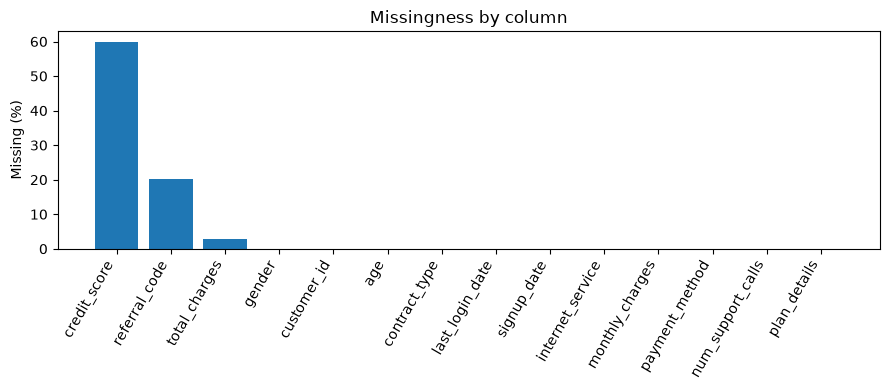

In [4]:
m = quality["missing_pct"].sort_values(ascending=False)
plt.figure(figsize=(9,4))
plt.bar(m.index, m.values)
plt.ylabel("Missing (%)")
plt.title("Missingness by column")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


## 2. Cleaning decisions

- Remove exact duplicate records before clustering.
- Exclude `customer_id` because it is an identifier.
- Exclude `referral_code` because it is high-cardinality and mostly unique.
- Keep `gender` for EDA but do not use it as a clustering input because the requested segmentation is primarily behavioral/commercial.
- Convert signup/login dates and derive tenure and recency.
- Parse `plan_details` into structured plan tier and speed.
- Impute missing cumulative charges from monthly charges and observed tenure.
- Exclude `credit_score` from clustering because roughly 60% of the column is missing.


In [5]:
clean = df.drop_duplicates().copy()
clean["signup_date"] = pd.to_datetime(clean["signup_date"], errors="coerce")
clean["last_login_date"] = pd.to_datetime(clean["last_login_date"], errors="coerce")
reference_date = clean["last_login_date"].max()

clean["tenure_days"] = (clean["last_login_date"] - clean["signup_date"]).dt.days.clip(lower=0)
clean["recency_days"] = (reference_date - clean["last_login_date"]).dt.days.clip(lower=0)

parsed = clean["plan_details"].str.extract(r"^(.*?) Plan - \$([\d.]+)/mo - (\d+)Mbps")
parsed.columns = ["plan_tier", "plan_price", "speed_mbps"]
clean = pd.concat([clean, parsed], axis=1)
clean["plan_price"] = pd.to_numeric(clean["plan_price"], errors="coerce")
clean["speed_mbps"] = pd.to_numeric(clean["speed_mbps"], errors="coerce")

tenure_months = clean["tenure_days"] / 30.44
clean["total_charges_filled"] = clean["total_charges"].fillna(
    clean["monthly_charges"] * tenure_months.clip(lower=1)
)

print("Rows after exact-deduplication:", len(clean))
print("Reference date:", reference_date.date())
print("Plan parsing failures:", clean["plan_tier"].isna().sum())
print("Monthly charge == parsed plan price:",
      np.isclose(clean["monthly_charges"], clean["plan_price"]).all())


Rows after exact-deduplication: 100000
Reference date: 2026-06-01
Plan parsing failures: 0
Monthly charge == parsed plan price: True


## 3. Preprocessing and feature matrix

In [6]:
NUMERIC_FEATURES = [
    "age", "monthly_charges", "total_charges_filled",
    "num_support_calls", "tenure_days", "recency_days", "speed_mbps"
]
CATEGORICAL_FEATURES = [
    "contract_type", "internet_service", "payment_method", "plan_tier"
]

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), NUMERIC_FEATURES),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), CATEGORICAL_FEATURES)
])

X = preprocessor.fit_transform(clean)
print("Transformed matrix:", X.shape)


Transformed matrix: (100000, 21)


## 4. Select the number of clusters

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.218861,3450.178851,1.619585
1,3,0.233655,3092.611502,1.666363
2,4,0.157727,2552.793696,2.102567
3,5,0.150262,2195.420137,1.951048
4,6,0.127549,1941.185625,2.151661
5,7,0.118451,1757.045258,2.078984
6,8,0.112580,1597.338347,2.136733


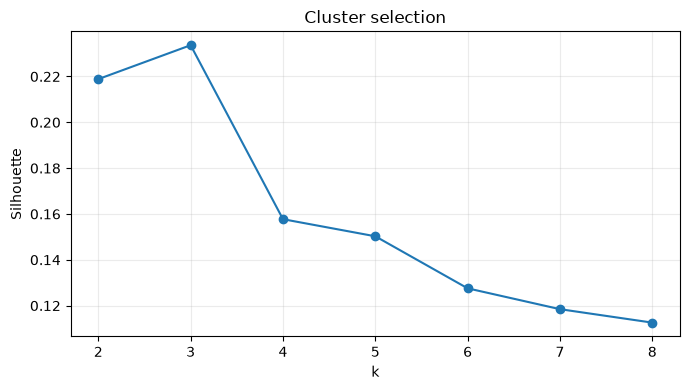

In [7]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(clean), size=min(12000, len(clean)), replace=False)

scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X[sample_idx])
    scores.append({
        "k": k,
        "silhouette": silhouette_score(X[sample_idx], labels),
        "calinski_harabasz": calinski_harabasz_score(X[sample_idx], labels),
        "davies_bouldin": davies_bouldin_score(X[sample_idx], labels)
    })

scores = pd.DataFrame(scores)
display(scores)

plt.figure(figsize=(7,4))
plt.plot(scores["k"], scores["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Cluster selection")
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()


The selected solution is **k=3**. It gives the strongest silhouette among the tested values and produces interpretable separation in spend, tenure, contract type and login recency.

In [8]:
model = KMeans(n_clusters=3, random_state=42, n_init=20, max_iter=300)
clean["cluster"] = model.fit_predict(X)

cluster_names = {
    0: "Active Standard-Market Customers",
    1: "High-Value Long-Term Customers",
    2: "Dormant / Low-Recent-Activity Customers"
}
clean["segment_name"] = clean["cluster"].map(cluster_names)
print(clean["segment_name"].value_counts())


segment_name
Active Standard-Market Customers           53614
High-Value Long-Term Customers             29303
Dormant / Low-Recent-Activity Customers    17083
Name: count, dtype: int64


## 5. Profile the resulting segments

In [9]:
profile_cols = [
    "monthly_charges","total_charges_filled",
    "num_support_calls","tenure_days","recency_days","speed_mbps"
]
display(clean.groupby("cluster")[profile_cols].mean().round(2))

for col in ["contract_type","plan_tier","internet_service","payment_method"]:
    print("\n", col)
    display(pd.crosstab(clean["cluster"], clean[col], normalize="index").round(3))


,monthly_charges,total_charges_filled,num_support_calls,tenure_days,recency_days,speed_mbps
cluster,,,,,,
0,55.14,827.96,1.54,414.30,20.11,194.76
1,94.68,4458.98,0.64,1474.21,10.91,194.95
2,54.98,2173.71,3.40,1021.42,238.26,195.65



 contract_type


contract_type,Month-to-month,One year,Two year
cluster,,,
0,0.659,0.243,0.098
1,0.124,0.298,0.577
2,0.459,0.348,0.194



 plan_tier


plan_tier,Basic,Premium,Standard,Ultra
cluster,,,,
0,0.232,0.262,0.504,0.002
1,0.004,0.503,0.019,0.473
2,0.497,0.007,0.496,0.000



 internet_service


internet_service,DSL,Fiber optic,No
cluster,,,
0,0.350,0.454,0.196
1,0.354,0.444,0.202
2,0.351,0.444,0.205



 payment_method


payment_method,Bank transfer,Credit card,Mailed check,UPI
cluster,,,,
0,0.249,0.250,0.250,0.251
1,0.249,0.249,0.249,0.254
2,0.256,0.244,0.252,0.249


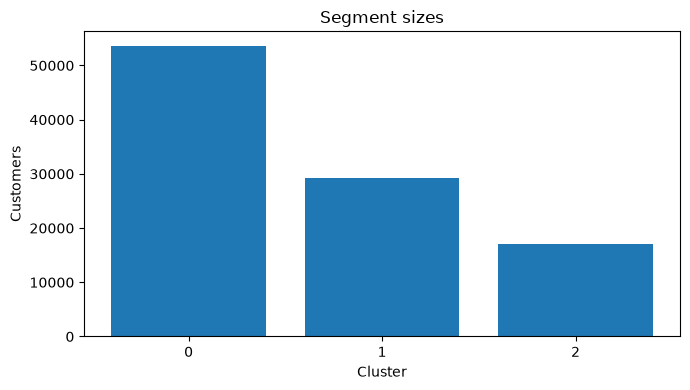

In [10]:
counts = clean["cluster"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.title("Segment sizes")
plt.tight_layout()
plt.show()


## 6. Save the loadable clustering artifact

In [11]:
artifact = {
    "artifact_version": "1.0",
    "model_type": "KMeans",
    "n_clusters": 3,
    "reference_date": str(reference_date.date()),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "preprocessor": preprocessor,
    "model": model,
    "cluster_names": cluster_names,
}
joblib.dump(artifact, "segment_model.joblib")
print("Saved segment_model.joblib")


Saved segment_model.joblib
